# 🛃 Vision Edge Gate — Fine-tune YOLOv11n
## Zero-Stop E-Border | Container Number Detection

**Pipeline:**
```
Dataset (YOLO format) → Fine-tune YOLOv11n → best.pt → Download về máy
```

**Thời gian ước tính:** ~30-40 phút trên Colab T4 GPU

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bước 0 — Kiểm tra GPU

In [ ]:
!nvidia-smi
import torch
print(f'\nPyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Sat May  2 10:25:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Bước 1 — Cài đặt thư viện

In [ ]:
!pip install -q "ultralytics==8.4.46" --upgrade
from ultralytics import YOLO
print('✅ Ultralytics installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics installed


## Bước 2 — Upload dataset

Upload file `.zip` dataset (đã download từ Roboflow dạng YOLOv11) lên Colab.

> **Lưu ý:** Chỉ cần upload folder `train` và file `data.yaml` là đủ (valid tạo từ train nếu thiếu).

## Bước 3 — Chuẩn bị data.yaml

In [ ]:
import yaml, os
from pathlib import Path

train_path = "/content/drive/MyDrive/CODE UNIVERSITY/AIB3/train"
valid_path = "/content/drive/MyDrive/CODE UNIVERSITY/AIB3/valid"
# Ghi lại data.yaml với đường dẫn tuyệt đối
new_config = {
    'train': train_path,
    'val':   valid_path,
    'nc':    1,
    'names': ['container_number']
}

fixed_yaml = '/content/drive/MyDrive/CODE UNIVERSITY/AIB3/data.yaml'
with open(fixed_yaml, 'w') as f:
    yaml.dump(new_config, f, default_flow_style=False)

print(f'\n✅ data.yaml đã fix:')
print(f'  train: {train_path}')
print(f'  val:   {valid_path}')
print(f'  nc:    1')
print(f'  names: [container_number]')

# Đếm số ảnh
train_image = train_path + '/images'
valid_image = valid_path + '/images'
n_train = len(list(Path(train_image).glob('*.jpg'))) + len(list(Path(train_image).glob('*.png')))
n_valid = len(list(Path(valid_image).glob('*.jpg'))) + len(list(Path(valid_image).glob('*.png')))
print(f'\n📊 Train: {n_train} ảnh | Valid: {n_valid} ảnh')


✅ data.yaml đã fix:
  train: /content/drive/MyDrive/CODE UNIVERSITY/AIB3/train
  val:   /content/drive/MyDrive/CODE UNIVERSITY/AIB3/valid
  nc:    1
  names: [container_number]

📊 Train: 1534 ảnh | Valid: 231 ảnh


## Bước 4 — Fine-tune YOLOv11n

Các tham số quan trọng:
- `epochs=50` — đủ để converge với 1.5k ảnh
- `imgsz=640` — chuẩn YOLO
- `batch=16` — phù hợp T4 GPU 15GB
- `patience=15` — early stopping nếu không cải thiện

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv11n (backbone đã train trên COCO)
model = YOLO('yolo11n.pt')
print('✅ Loaded YOLOv11n pretrained')
print(f'Model parameters: {sum(p.numel() for p in model.model.parameters()):,}')

✅ Loaded YOLOv11n pretrained
Model parameters: 2,624,080


In [ ]:
import numpy as np
print(np.__version__)
print(np.__file__)

2.0.2
/usr/local/lib/python3.12/dist-packages/numpy/__init__.py


In [ ]:
results = model.train(
    data='/content/drive/MyDrive/CODE UNIVERSITY/AIB3/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    device=0,
    project='/content/drive/MyDrive/CODE UNIVERSITY/AIB3/runs',
    name='container_detector',
    exist_ok=True,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,
    flipud=0.3,           # Giữ 0.3 — ảnh dọc cần flip dọc để augment
    fliplr=0.3,           # Giữ 0.3
    mosaic=0.8,
    translate=0.1,
    scale=0.4,
    degrees=15.0,         # Tăng từ 5 → 15 — cover cả góc dọc lẫn ngang

    # Optimizer
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,

    verbose=True,
    save=True,
    save_period=10,
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CODE UNIVERSITY/AIB3/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.3, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=container_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ada

## Bước 5 — Đánh giá kết quả

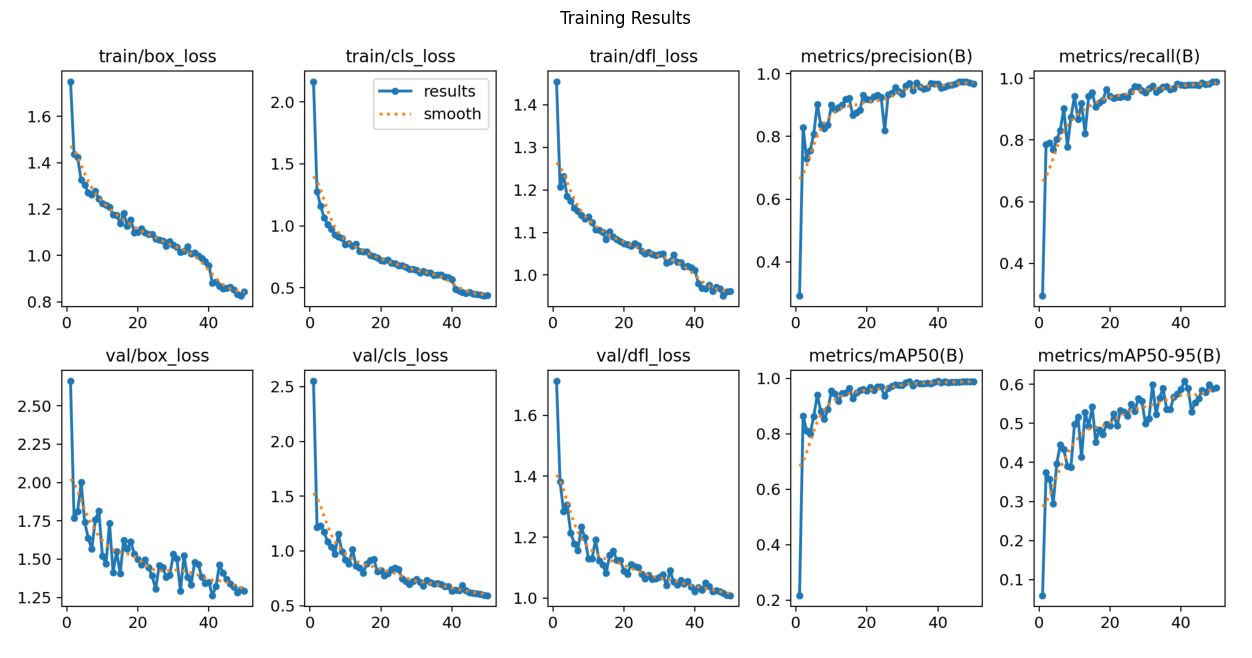


✅ best.pt location: /content/drive/MyDrive/CODE UNIVERSITY/AIB3/runs/container_detector/weights/best.pt
   File size: 5.2 MB


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

run_dir = Path('/content/drive/MyDrive/CODE UNIVERSITY/AIB3/runs/container_detector')

# Hiển thị training curves
results_png = run_dir / 'results.png'
if results_png.exists():
    img = mpimg.imread(str(results_png))
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Results')
    plt.show()

# In metrics
best_pt = run_dir / 'weights' / 'best.pt'
print(f'\n✅ best.pt location: {best_pt}')
print(f'   File size: {best_pt.stat().st_size / 1024 / 1024:.1f} MB')

In [ ]:
# Validate trên valid set
best_model = YOLO(str(run_dir / 'weights' / 'best.pt'))
val_results = best_model.val(data='/content/drive/MyDrive/CODE UNIVERSITY/AIB3/data.yaml', verbose=True)

print('\n📊 Validation Metrics:')
print(f'  mAP50:    {val_results.results_dict.get("metrics/mAP50(B)", 0):.4f}')
print(f'  mAP50-95: {val_results.results_dict.get("metrics/mAP50-95(B)", 0):.4f}')
print(f'  Precision:{val_results.results_dict.get("metrics/precision(B)", 0):.4f}')
print(f'  Recall:   {val_results.results_dict.get("metrics/recall(B)", 0):.4f}')

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.7 ms, read: 71.0±52.5 MB/s, size: 332.9 KB)
val: Scanning /content/drive/MyDrive/CODE UNIVERSITY/AIB3/valid/labels.cache... 231 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 231/231 57.0Mit/s 0.0s
val: /content/drive/MyDrive/CODE UNIVERSITY/AIB3/valid/images/1-142833001-OCR-AS-B01_jpg.rf.7TVBnBwuM8yxVWfbTvu2.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/CODE UNIVERSITY/AIB3/valid/images/1-142833001-OCR-RF-D01_jpg.rf.iABrOjcpeuLAlgMZb9Xv.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/CODE UNIVERSITY/AIB3/valid/images/1-144334001-OCR-RF-D01_jpg.rf.gYURJSQuiIDRlIn3V8dY.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.1it/s 4.9s
                

## Bước 6 — Test với ảnh thực tế

In [ ]:
# # Upload ảnh test
# from google.colab import files as colab_files
# import cv2
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg
# import numpy as np

# print('Upload ảnh container để test...')
# test_uploaded = colab_files.upload()

# for fname in test_uploaded.keys():
#     img = cv2.imread(fname)
#     results = best_model(img, conf=0.25, verbose=False)

#     annotated = results[0].plot()
#     annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

#     plt.figure(figsize=(12, 8))
#     plt.imshow(annotated_rgb)
#     plt.title(f'Detection result: {fname}')
#     plt.axis('off')
#     plt.show()

#     for box in results[0].boxes:
#         conf = float(box.conf[0])
#         x1,y1,x2,y2 = map(int, box.xyxy[0])
#         print(f'  ✅ Detected bounding box: ({x1},{y1}) → ({x2},{y2}) | conf: {conf:.2%}')

## Bước 7 — Download best.pt về máy

In [ ]:
from google.colab import files
from pathlib import Path
import shutil

best_pt = Path('/content/drive/MyDrive/CODE UNIVERSITY/AIB3/runs/container_detector/weights/best.pt')

# Copy ra root để dễ download
shutil.copy(best_pt, '/content/drive/MyDrive/CODE UNIVERSITY/AIB3/container_best.pt')

print(f'📦 Đang download container_best.pt ({best_pt.stat().st_size/1024/1024:.1f} MB)...')
files.download('/content/drive/MyDrive/CODE UNIVERSITY/AIB3/container_best.pt')
print('✅ Download hoàn tất!')
print('\n👉 Bước tiếp theo: đặt file container_best.pt vào thư mục vision_edge_gate/')

📦 Đang download container_best.pt (5.2 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download hoàn tất!

👉 Bước tiếp theo: đặt file container_best.pt vào thư mục vision_edge_gate/
